# Discounted value 

Text(0, 0.5, 'Time')

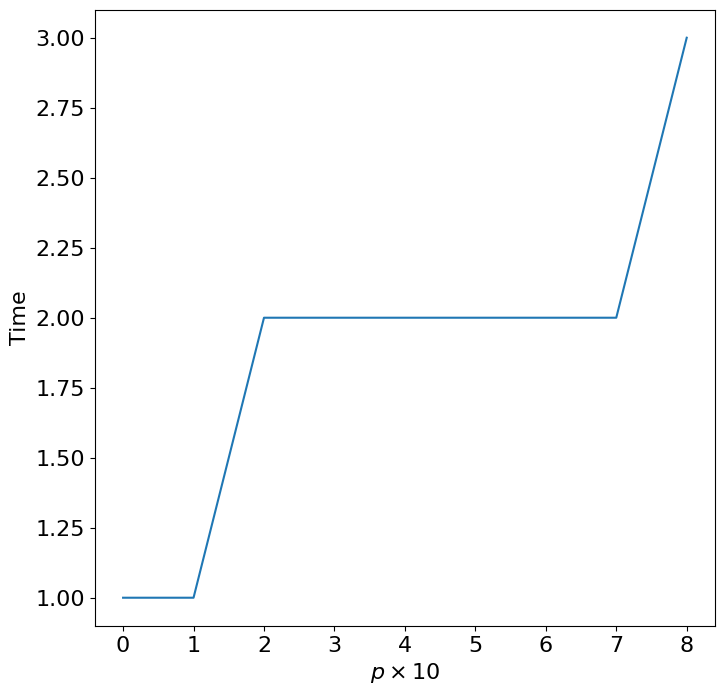

In [21]:
import numpy as np
import matplotlib.pyplot as plt

K = 10
c = 3
iteration = 1000
n = 10
p = 0.2
alpha = 0.8

result = []
als = []
als.append(0.0)
for i in range(8):
    als.append(als[i] + 1 / 10)

for p in als:
    J = np.random.rand(n + 1)
    for it in range(iteration):
        for i in range(n):
            J[i] = min(
                K + alpha * (1 - p) * J[0] + alpha * p * J[1],
                c * i + alpha * (1 - p) * J[i] + alpha * p * J[i + 1],
            )
        J[-1] = K + alpha * (1 - p) * J[0] + alpha * p * J[1]

    for i in range(len(J) - 1):
        if J[i] == J[i + 1]:
            result.append(i)
            break

name = "c"
fontsize = 16
plt.figure(figsize=(8, 8))
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.plot(result)
# plt.xlabel(name, fontsize=fontsize)
plt.xlabel(r"$p \times 10$", fontsize=fontsize)
plt.ylabel("Time", fontsize=fontsize)

# Average cost

Text(0, 0.5, 'Time')

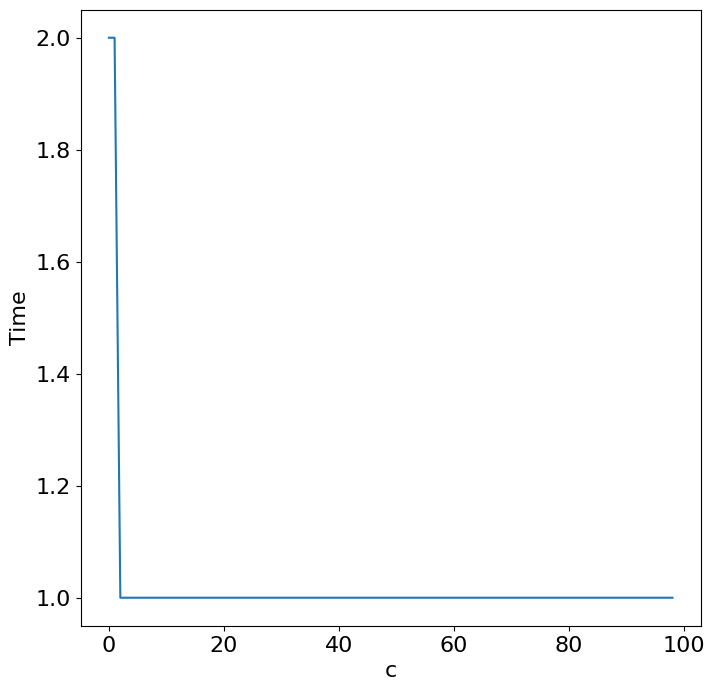

In [22]:
import numpy as np

K = 10
c = 3
iteration = 100
n = 10
p = 0.2
alpha = 1

result = []
for c in range(1, 100):
    h0 = np.zeros(n + 1)
    lambdax = 0
    for it in range(iteration):
        h = h0.copy()
        for i in range(n):
            h0[i] = (
                min(
                    K + alpha * (1 - p) * h[0] + alpha * p * h[1],
                    c * i + alpha * (1 - p) * h[i] + alpha * p * h[i + 1],
                )
                - lambdax
            )
        h0[-1] = K + alpha * (1 - p) * h[0] + alpha * p * h[1] - lambdax
        # print(h0)

        tmp = [
            c * i + alpha * (1 - p) * h0[i] + alpha * p * h0[i + 1] for i in range(n)
        ]
        tmp.append(K + alpha * (1 - p) * h0[0] + alpha * p * h0[1])
        lambdax = min(tmp)

    for i in range(len(h0) - 1):
        if h0[i] == h0[i + 1]:
            result.append(i)
            break

name = "c"
fontsize = 16
plt.figure(figsize=(8, 8))
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.plot(result)
plt.xlabel(name, fontsize=fontsize)
# plt.xlabel(r"$p \times 10$", fontsize=fontsize)
plt.ylabel("Time", fontsize=fontsize)

# Time

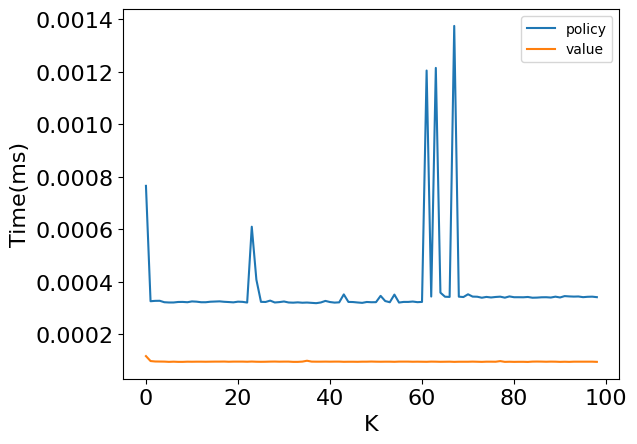

In [32]:
import time
import numpy as np
import pandas as pd

K = 10
c = 3
iteration = 10
n = 10
p = 0.2
alpha = 0.8

ts_value = []
for K in range(1, 100):
    start = time.time()
    J = np.random.rand(n + 1)
    for it in range(iteration):
        for i in range(n):
            J[i] = min(
                K + alpha * (1 - p) * J[0] + alpha * p * J[1],
                c * i + alpha * (1 - p) * J[i] + alpha * p * J[i + 1],
            )
        J[-1] = K + alpha * (1 - p) * J[0] + alpha * p * J[1]
    end = time.time() - start
    ts_value.append(end)


def g(s, action):
    if action == 1:
        return K
    if action == 0:
        return c * s


ts_policy = []
for K in range(1, 100):
    start = time.time()
    mu = np.ones(n + 1)
    M = np.zeros((n + 1, n + 1))

    for it in range(iteration):
        M = np.zeros((n + 1, n + 1))
        M[n][n], M[n][0], M[n][1] = 1, -alpha * (1 - p), -alpha * p
        for i in range(n):
            if mu[i] == 0:
                M[i][i] = 1 - alpha * (1 - p)
                M[i][i + 1] = -alpha * p
            else:
                if i == 0:
                    M[0][0] = 1 - alpha * (1 - p)
                    M[i][1] = -alpha * p
                else:
                    M[i][i], M[i][0], M[i][1] = 1, -alpha * (1 - p), -alpha * p

        G = np.array([g(i, mu[i]) for i in range(n)] + [K])
        J = np.dot(np.linalg.inv(M), G)

        for i in range(n):
            cost1 = K + alpha * (1 - p) * J[0] + alpha * p * J[1]
            cost0 = c * i + alpha * (1 - p) * J[i] + alpha * p * J[i + 1]
            if cost1 > cost0:
                mu[i] = 0
            else:
                mu[i] = 1

    end = time.time() - start
    ts_policy.append(end)

df = pd.DataFrame({"policy": ts_policy, "value": ts_value})
df.plot()
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.xlabel("K", fontsize=fontsize)
plt.ylabel("Time(ms)", fontsize=fontsize)
plt.legend()
plt.show()